<a href="https://colab.research.google.com/github/Aditya200247/F1-Podium-Predictor/blob/main/Formula_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import glob, os
csv_files=glob.glob('*.csv')
dfs={}
for f in csv_files:
    name = os.path.splitext(os.path.basename(f))[0]
    dfs[name] = pd.read_csv(f, na_values=['\\N'])
    print(f"{name}: shape={dfs[name].shape}")
    print(dfs[name].head(2))
    print()



driver_standings: shape=(34863, 7)
   driverStandingsId  raceId  driverId  points  position positionText  wins
0                  1      18         1    10.0         1            1     1
1                  2      18         2     8.0         2            2     0

circuits: shape=(77, 9)
   circuitId   circuitRef                            name      location  \
0          1  albert_park  Albert Park Grand Prix Circuit     Melbourne   
1          2       sepang    Sepang International Circuit  Kuala Lumpur   

     country       lat      lng  alt  \
0  Australia -37.84970  144.968   10   
1   Malaysia   2.76083  101.738   18   

                                                 url  
0  http://en.wikipedia.org/wiki/Melbourne_Grand_P...  
1  http://en.wikipedia.org/wiki/Sepang_Internatio...  

qualifying: shape=(10494, 9)
   qualifyId  raceId  driverId  constructorId  number  position        q1  \
0          1      18         1              1      22         1  1:26.572   
1          2    

In [4]:
for name, df in dfs.items():
    print(f"DataFrame: {name}")
    print(df.head())
    print()

DataFrame: driver_standings
   driverStandingsId  raceId  driverId  points  position positionText  wins
0                  1      18         1    10.0         1            1     1
1                  2      18         2     8.0         2            2     0
2                  3      18         3     6.0         3            3     0
3                  4      18         4     5.0         4            4     0
4                  5      18         5     4.0         5            5     0

DataFrame: circuits
   circuitId   circuitRef                            name      location  \
0          1  albert_park  Albert Park Grand Prix Circuit     Melbourne   
1          2       sepang    Sepang International Circuit  Kuala Lumpur   
2          3      bahrain   Bahrain International Circuit        Sakhir   
3          4    catalunya  Circuit de Barcelona-Catalunya      Montmeló   
4          5     istanbul                   Istanbul Park      Istanbul   

     country       lat        lng  alt  \
0 

In [6]:
dfs['sprint_results'].head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
0,1,1061,830,9,33,2,1.0,1,1,3,17,25:38.426,1538426.0,14.0,1:30.013,1
1,2,1061,1,131,44,1,2.0,2,2,2,17,+1.430,1539856.0,17.0,1:29.937,1
2,3,1061,822,131,77,3,3.0,3,3,1,17,+7.502,1545928.0,17.0,1:29.958,1
3,4,1061,844,6,16,4,4.0,4,4,0,17,+11.278,1549704.0,16.0,1:30.163,1
4,5,1061,846,1,4,6,5.0,5,5,0,17,+24.111,1562537.0,16.0,1:30.566,1


### Distribution of Fastest Laps in Sprint Results

This histogram visualizes the distribution of 'fastestLap' values from the `sprint_results` DataFrame. It helps to identify the most common fastest lap times and any unusual values.

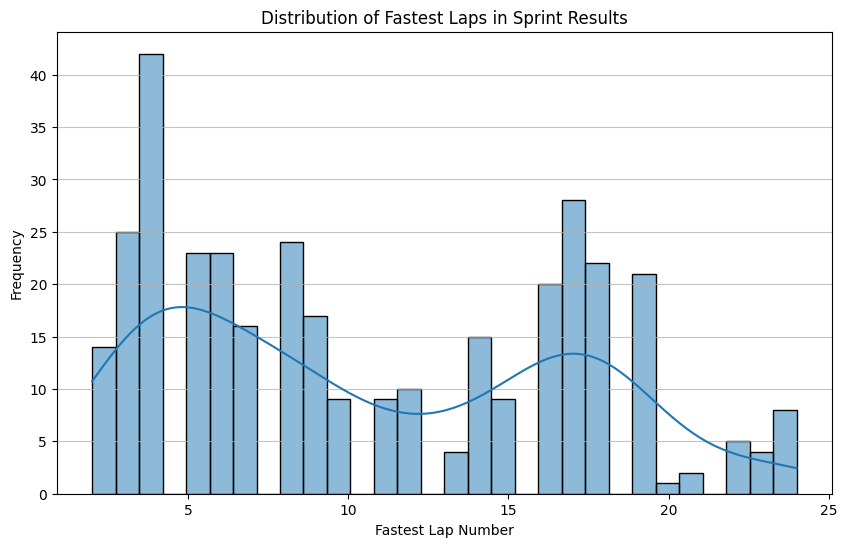

In [7]:
sprint_results_df = dfs['sprint_results']
sprint_results_df['fastestLap'] = pd.to_numeric(sprint_results_df['fastestLap'], errors='coerce')
fastest_lap_data = sprint_results_df['fastestLap'].dropna()
plt.figure(figsize=(10, 6))
sns.histplot(fastest_lap_data, bins=30, kde=True)
plt.title('Distribution of Fastest Laps in Sprint Results')
plt.xlabel('Fastest Lap Number')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()